In [25]:
#impoer libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

#load the dataset
df = pd.read_csv('Listings.csv', encoding='latin1')

#data cleaning
df.dropna(inplace=True)
pd.set_option('display.max_columns', None)
df = df.drop(['listing_id', 'host_id'], axis=1)

# Encode categorical variables
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [26]:
#Change dummies into 0 and 1, and change dtype into int
df['instant_bookable'] = df['instant_bookable'].replace({'t': 1, 'f': 0})
df['instant_bookable'] = df['instant_bookable'].astype(int)
df['host_is_superhost'] = df['host_is_superhost'].replace({'t': 1, 'f': 0})
df['host_is_superhost'] = df['host_is_superhost'].astype(int)
df['host_has_profile_pic'] = df['host_has_profile_pic'].replace({'t': 1, 'f': 0})
df['host_has_profile_pic'] = df['host_has_profile_pic'].astype(int)
df['host_identity_verified'] = df['host_identity_verified'].replace({'t': 1, 'f': 0})
df['host_identity_verified'] = df['host_identity_verified'].astype(int)

In [27]:
#Name columns
name = df['name']
host_since = df['host_since']
host_location = df['host_location']
host_response_time = df['host_response_time']
host_response_rate = df['host_response_rate']
host_acceptance_rate = df['host_acceptance_rate']
host_is_superhost = df['host_is_superhost']
host_total_listings_count = df['host_total_listings_count']
host_has_profile_pic = df['host_has_profile_pic']
host_identity_verified = df['host_identity_verified']
neighbourhood = df['neighbourhood']
district = df['district']
city = df['city']
latitude = df['latitude']
property_type = df['property_type']
room_type = df['room_type']
room_type = df['room_type']
accommodates = df['accommodates']
bedrooms = df['bedrooms']
amenities = df['amenities']
price = df['price']
minimum_nights = df['minimum_nights']
maximum_nights = df['maximum_nights']
review_scores_rating = df['review_scores_rating']
review_scores_accuracy = df['review_scores_accuracy']
review_scores_cleanliness = df['review_scores_cleanliness']
review_scores_checkin = df['review_scores_checkin']
review_scores_communication = df['review_scores_communication']
review_scores_location = df['review_scores_location']
review_scores_value = df['review_scores_value']
instant_bookable = df['instant_bookable']

In [28]:
#Prepare data for modeling
model_df = df.copy()

for col in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
    model_df[col] = model_df[col].replace({'t': 1, 'f': 0}).astype(int)

model_df['host_since'] = pd.to_datetime(model_df['host_since'], errors='coerce')
model_df['host_years'] = (pd.Timestamp('2024-01-01') - model_df['host_since']).dt.days / 365

model_df['amenity_count'] = model_df['amenities'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)

response_order = {'within an hour': 4, 'within a few hours': 3, 'within a day': 2, 'a few days or more': 1}
model_df['host_response_time_enc'] = model_df['host_response_time'].map(response_order).fillna(0)

model_df = pd.get_dummies(model_df, columns=['room_type', 'district'], drop_first=True)

In [29]:
#Select features and target
numeric_base = [
    'host_response_rate', 'host_acceptance_rate', 'host_total_listings_count',
    'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
    'host_years', 'host_response_time_enc', 'latitude', 'longitude',
    'accommodates', 'bedrooms', 'minimum_nights', 'maximum_nights',
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'instant_bookable', 'amenity_count'
]
ohe_cols = [c for c in model_df.columns if c.startswith('room_type_') or c.startswith('district_')]
feature_cols = numeric_base + ohe_cols

X = model_df[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
y = pd.to_numeric(model_df['price'], errors='coerce').fillna(0)

mask = y < y.quantile(0.99)
X, y = X[mask], y[mask]

In [30]:
#Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Model training
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'model': model, 'preds': preds,
        'MAE':  mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R²':   r2_score(y_test, preds)
    }
    print(f"{name:25s}  MAE=${results[name]['MAE']:.2f}  RMSE=${results[name]['RMSE']:.2f}  R²={results[name]['R²']:.4f}")

Linear Regression          MAE=$47.20  RMSE=$76.68  R²=0.4538
Random Forest              MAE=$39.69  RMSE=$69.20  R²=0.5552
Gradient Boosting          MAE=$39.83  RMSE=$66.90  R²=0.5843


Text(0.5, 1.0, 'Gradient Boosting – Actual vs Predicted')

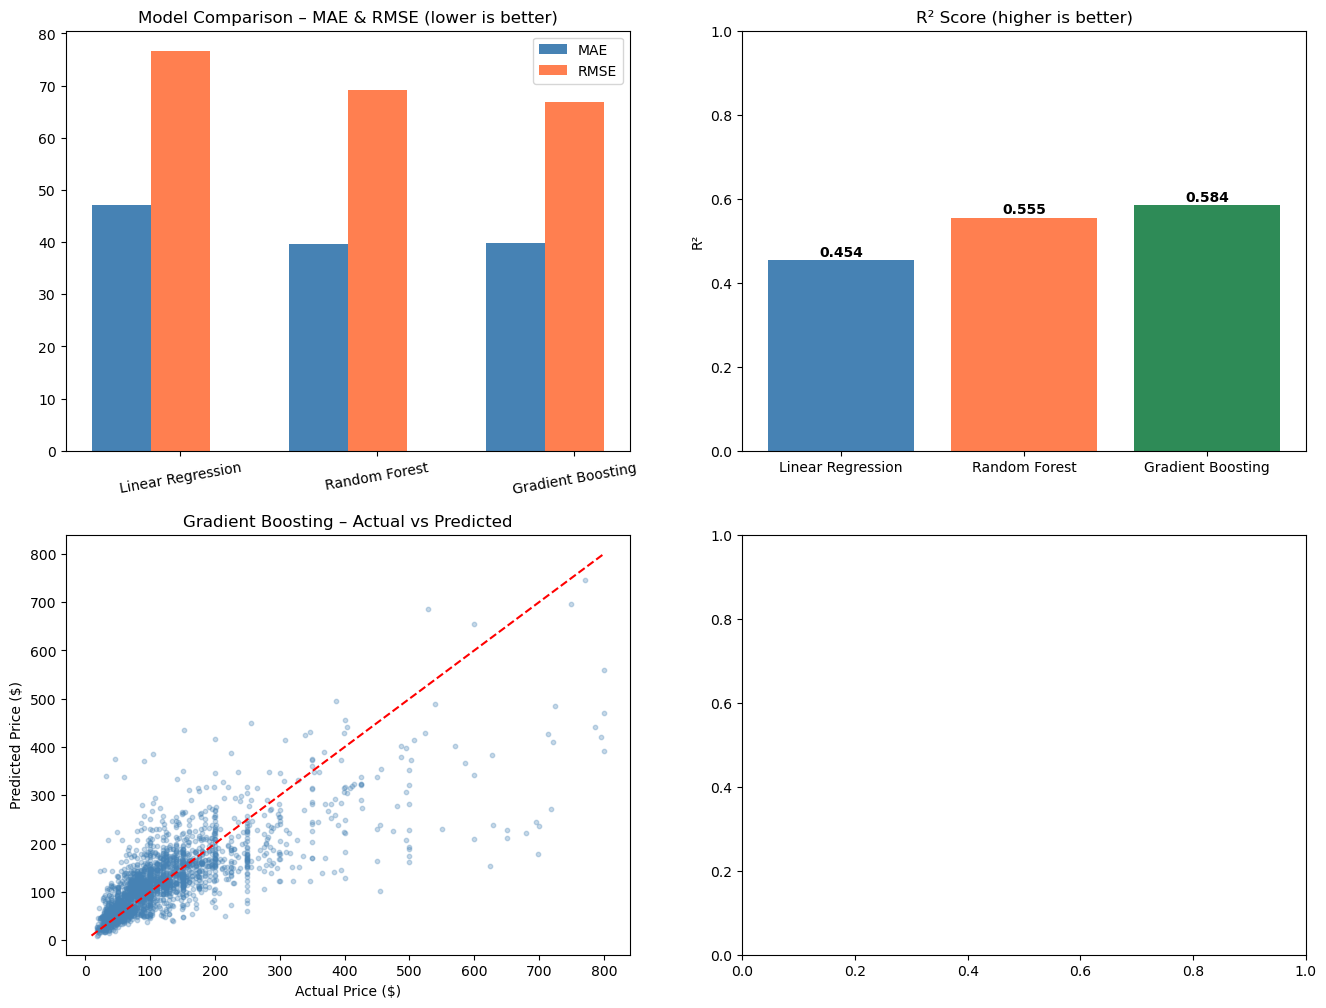

In [31]:
#Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_df = pd.DataFrame({m: {'MAE': v['MAE'], 'RMSE': v['RMSE'], 'R²': v['R²']}
                            for m, v in results.items()}).T

# MAE & RMSE comparison
x, w = np.arange(len(metrics_df)), 0.3
axes[0, 0].bar(x - w, metrics_df['MAE'],  w, label='MAE',  color='steelblue')
axes[0, 0].bar(x,     metrics_df['RMSE'], w, label='RMSE', color='coral')
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(metrics_df.index, rotation=10)
axes[0, 0].set_title('Model Comparison – MAE & RMSE (lower is better)'); axes[0, 0].legend()

# R² comparison
axes[0, 1].bar(metrics_df.index, metrics_df['R²'], color=['steelblue', 'coral', 'seagreen'])
axes[0, 1].set_ylim(0, 1); axes[0, 1].set_title('R² Score (higher is better)'); axes[0, 1].set_ylabel('R²')
for i, v in enumerate(metrics_df['R²']):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Actual vs Predicted (best model)
best_name = max(results, key=lambda m: results[m]['R²'])
best_preds = results[best_name]['preds']
axes[1, 0].scatter(y_test, best_preds, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[1, 0].plot(lims, lims, 'r--', lw=1.5)
axes[1, 0].set_xlabel('Actual Price ($)'); axes[1, 0].set_ylabel('Predicted Price ($)')
axes[1, 0].set_title(f'{best_name} – Actual vs Predicted')

In [32]:
# Feature importance
best_tree_name = 'Gradient Boosting' if results['Gradient Boosting']['R²'] >= results['Random Forest']['R²'] else 'Random Forest'
importances = pd.Series(results[best_tree_name]['model'].feature_importances_, index=feature_cols).nlargest(15)
importances[::-1].plot(kind='barh', ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title(f'Top 15 Feature Importances – {best_tree_name}'); axes[1, 1].set_xlabel('Importance')

plt.suptitle('Airbnb Price Prediction', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nBest model: {best_name}  |  R²={results[best_name]['R²']:.4f}  |  MAE=${results[best_name]['MAE']:.2f}  |  RMSE=${results[best_name]['RMSE']:.2f}")

<Figure size 640x480 with 0 Axes>


Best model: Gradient Boosting  |  R²=0.5843  |  MAE=$39.83  |  RMSE=$66.90
